In [8]:
# Import the module
import importlib
import IsovizPy as ja
import pandas as pd
import gffutils

In [9]:
!hostname

ne1dc6-005.nygenome.org


In [28]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = '/gpfs/commons/home/kisaev/gencode.v47.annotation.gtf' 
gtf_file = '/gpfs/commons/home/kisaev/gencode.v47.basic.annotation.gtf'  
print(gtf_file)

# db = ja.create_db(gtf_file, "human_v47_gencode_basic")

/gpfs/commons/home/kisaev/gencode.v47.basic.annotation.gtf


In [29]:
# Path to the database file created previously
db_path = "human_v47_gencode_annotation"
db_path = "human_v47_gencode_basic"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

In [36]:
gene_name = 'BCL2L1'
gene_name = 'OAS1'
gene_name = "FGFR2"

print(f"Looking at isoforms for the gene {gene_name}")

Looking at isoforms for the gene FGFR2


In [37]:
# After making changes to IsovizPy, reload it
importlib.reload(ja)

<module 'IsovizPy' from '/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/IsovizPy.py'>

In [38]:
# Example usage when transcripts_list 
bcl2l1_trans = ["ENST00000677494.1",
"ENST00000456404.6",
"ENST00000678563.1",
"ENST00000676942.1",
"ENST00000420488.6",
"ENST00000439267.2",
"ENST00000307677.5",
"ENST00000376062.6",
"ENST00000677194.1",
"ENST00000434194.2",
"ENST00000450273.2",
"ENST00000376055.9",
"ENST00000422920.2",
"ENST00000676582.1",
"ENST00000678671.1"]

fgfr2_trans = ['ENST00000611527.1', 'ENST00000359354.6', 'ENST00000683035.1',
       'ENST00000369059.5', 'ENST00000457416.7', 'ENST00000356226.8',
       'ENST00000360144.7', 'ENST00000346997.6', 'ENST00000369056.5',
       'ENST00000683211.1', 'ENST00000358487.10', 'ENST00000351936.11',
       'ENST00000682550.1', 'ENST00000684153.1', 'ENST00000369061.8',
       'ENST00000357555.9', 'ENST00000613048.4', 'ENST00000369060.8',
       'ENST00000478859.5', 'ENST00000638709.2', 'ENST00000682772.1']
 
oas1_trans = ['ENST00000553185.2', 'ENST00000675868.2', 'ENST00000681700.1',
       'ENST00000680189.1', 'ENST00000680934.1', 'ENST00000679494.1',
       'ENST00000681228.1', 'ENST00000680659.1', 'ENST00000679987.1',
       'ENST00000202917.10', 'ENST00000679467.1', 'ENST00000445409.7',
       'ENST00000540589.3', 'ENST00000552526.2', 'ENST00000679971.1',
       'ENST00000680455.1', 'ENST00000550689.2', 'ENST00000679841.1',
       'ENST00000550883.2', 'ENST00000553152.2', 'ENST00000452357.7',
       'ENST00000551241.6']

In [39]:
new_order = fgfr2_trans

new_order = new_order[::-1]
transcript_ids = new_order

Plot saved to FGFR2_isoforms_plot_20241113_compression_0.1.pdf!


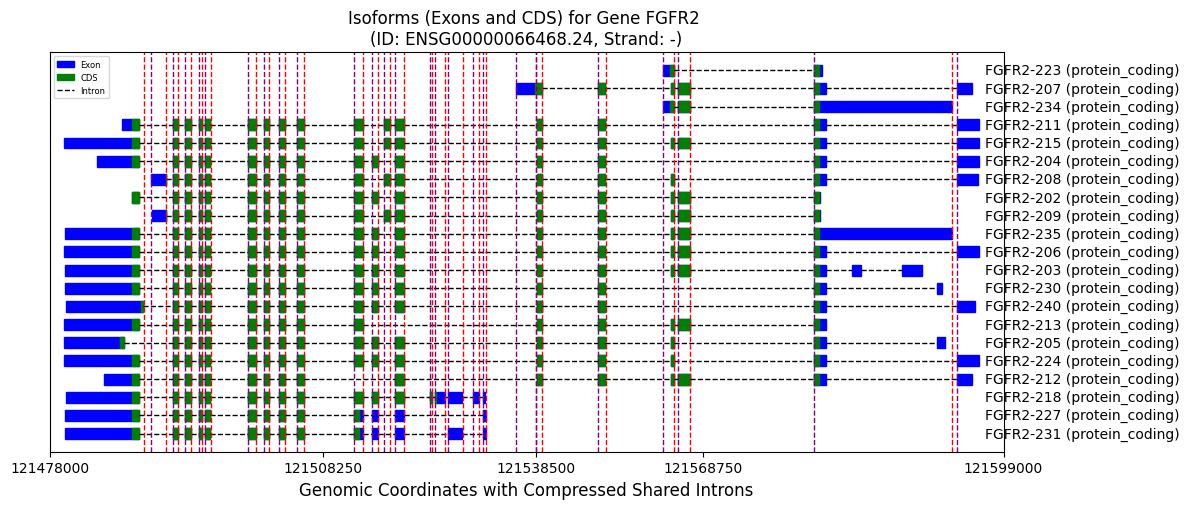

In [45]:
# After making changes to IsovizPy, reload it
importlib.reload(ja)

# transcript_ids = ja.fetch_transcripts_for_gene(db, gene_name)

# Step 2: Fetch transcript annotations
transcript_data = ja.fetch_transcripts_and_annotations(
    db,
    transcript_ids
)
    
# Step 3: Determine region boundaries
region_start, region_end = ja.determine_region_boundaries_from_transcripts(transcript_data)

exons = []
for transcript, values in transcript_data.items():
    for exon in values['exons']:
        exons.append((exon[0], exon[1]))

intronic_intervals = ja.get_intervals_not_overlapped_by_exons(
    region_start, 
    region_end, 
    exons
)

# Step 4: Plot isoforms
ja.plot_isoforms(
    db, 
    transcript_data, 
    region_start-100, 
    region_end+100, 
    base_width=12, 
    trans_height=0.2, 
    introns_list=intronic_intervals,
    plot_shared_inton_lines=True,
    compression_factor=0.1
)

Plot saved to FGFR2_isoforms_plot_20241113_compression_1.pdf!


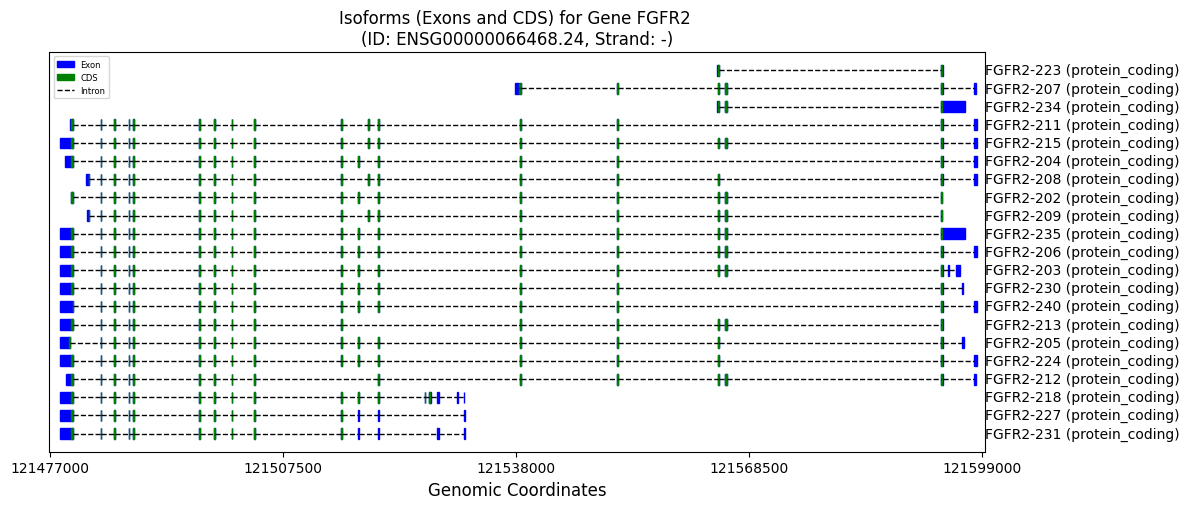

In [44]:
# Step 4: Plot isoforms
ja.plot_isoforms(
    db, 
    transcript_data, 
    region_start-1000, 
    region_end+1000, 
    base_width=12, 
    trans_height=0.2)